# E2 — The private diarist (*Philosophical Investigations* §258)

*A working demonstration of Beetle-Box experiment **E2**. Full write-up:
[`docs/e2_diarist.md`](../docs/e2_diarist.md). Runs on CPU in seconds.*

**§258, in one breath.** A diarist writes the sign "S" whenever a private sensation
recurs. There is no public criterion for "same again" — nothing outside the
diarist's own impressions to check against. Wittgenstein: absent an independent
check, "following the rule for S" and merely *seeming* to are indistinguishable —
"whatever is going to seem right to me is right."

We operationalize this: sensations are percept vectors drawn from `K` latent
**types** (the God's-eye ground truth the diarist never sees). The diarist names
each percept with a self-invented term, under **no correction**. Using the
God's-eye types as a ruler the diarist lacks, we ask: does a type keep getting the
same term? And what does any stability rest on?

The central knob is **memory** — the diary itself. We'll see that the diary can
*manufacture* the stability §258 says is impossible without a check — which is
exactly what makes the dilemma sharp.

In [1]:
import warnings, collections
import numpy as np
import matplotlib.pyplot as plt

from beetlebox.config import E2RunConfig, E2ExperimentConfig, PerceptConfig, DiaristConfig
from beetlebox.harness import E2RunManager
from beetlebox.analysis import e2

warnings.filterwarnings("ignore")
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermil": "#D55E00", "purple": "#CC79A7"}
plt.rcParams.update({
    "figure.figsize": (7.5, 4.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
})

def run(memory="full", noise=0.25, policy="prototype", steps=2000, window=20, seed=0):
    cfg = E2RunConfig(seed=seed)
    cfg.experiment = E2ExperimentConfig(num_steps=steps)
    cfg.percept = PerceptConfig(num_types=6, dim=8, noise=noise)
    cfg.diarist = DiaristConfig(policy=policy, memory=memory, window=window)
    return E2RunManager(cfg).run()
print("ready")

ready


## 1. The diary manufactures "same again"

The diarist matches each percept against its stored past impressions (its diary)
and reuses the nearest one's term, else coins a new one. The **memory** knob is the
diary: `full` (unbounded), `windowed` (only the last few impressions), or `none`
(no diary at all). Same percept stream, three amounts of memory.

In [2]:
results = {m: run(memory=m) for m in ["full", "windowed", "none"]}
for m, s in results.items():
    c = e2.consistency(s["types"], s["terms"])
    print(f"memory={m:8s}  consistency={c:.3f}  distinct_terms={s['distinct_terms']}")

memory=full      consistency=1.000  distinct_terms=5
memory=windowed  consistency=0.376  distinct_terms=36
memory=none      consistency=0.003  distinct_terms=2000


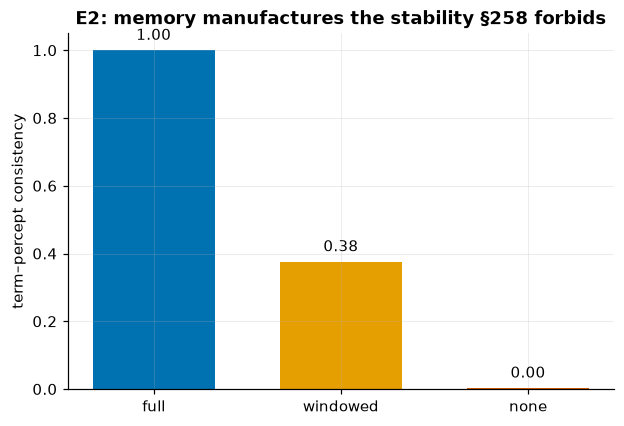

In [3]:
conds = ["full", "windowed", "none"]
cons = [e2.consistency(results[m]["types"], results[m]["terms"]) for m in conds]
fig, ax = plt.subplots(figsize=(6.4, 4.2))
bars = ax.bar(conds, cons, color=[OKABE["blue"], OKABE["orange"], OKABE["vermil"]], width=0.65)
ax.set_ylim(0, 1.05); ax.set_ylabel("term–percept consistency")
ax.set_title("E2: memory manufactures the stability §258 forbids")
for b, v in zip(bars, cons):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", va="bottom")
plt.show()

With a **full** diary, a type is named the same essentially every time
(consistency ≈ 1.0). With **no** diary, every sensation is named afresh
(consistency ≈ 0) — the diarist cannot even attempt "same again," because there is
nothing to compare against. **Memory produced the entire difference.**

That is the crux of the dilemma (§5 of the approach doc): the diary *is* the
agent's own record of how things previously *seemed*. So the stability it buys is
exactly what §258 warns is indistinguishable from a genuine, independent check.

## 2. With bounded memory, "same again" fades with time

If the diary only holds the last few impressions (`windowed`), a type that recurs
after a long gap has scrolled out of memory — so it gets a fresh term. We can see
this directly by conditioning consistency on the **gap** since a type last appeared.

windowed (small) memory: short-gap consistency=0.231  long-gap consistency=0.124


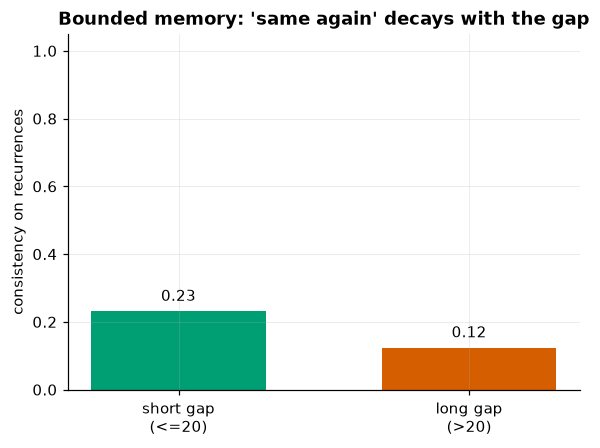

In [4]:
# A deliberately small window (8 impressions) so long-gap recurrences reliably
# scroll out of the diary before the type comes round again.
s = run(memory="windowed", window=8, steps=600)
g = e2.gap_conditioned_consistency(s["types"], s["terms"], s["gaps"], gap_threshold=10)
print(f"windowed (small) memory: short-gap consistency={g['short_gap']:.3f}  "
      f"long-gap consistency={g['long_gap']:.3f}")
fig, ax = plt.subplots(figsize=(6.0, 4.2))
bars = ax.bar(["short gap\n(<=20)", "long gap\n(>20)"], [g["short_gap"], g["long_gap"]],
              color=[OKABE["green"], OKABE["vermil"]], width=0.6)
ax.set_ylim(0, 1.05); ax.set_ylabel("consistency on recurrences")
ax.set_title("Bounded memory: 'same again' decays with the gap")
for b, v in zip(bars, [g["short_gap"], g["long_gap"]]):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", va="bottom")
plt.show()

## 3. When "same again" is genuinely ambiguous, memory can't save it

Raise the percept noise so the type clouds overlap — now a recurrence is not
obviously the same. Even a full diary can no longer stabilize the naming.

In [5]:
for noise in [0.25, 0.6, 0.9]:
    s = run(memory="full", noise=noise)
    print(f"noise={noise}  full-memory consistency="
          f"{e2.consistency(s['types'], s['terms']):.3f}  "
          f"distinct_terms={s['distinct_terms']}")

noise=0.25  full-memory consistency=1.000  distinct_terms=5


noise=0.6  full-memory consistency=0.719  distinct_terms=29


noise=0.9  full-memory consistency=0.171  distinct_terms=282


As the sensations blur together, "same again" loses its footing and consistency
falls — not because memory failed, but because there is no longer a fact of the
matter about recurrence for the diary to record.

## 4. Rich mode (optional) — a frontier model as the diarist

The same experiment runs with a pretrained model naming percept "readings" in
context, its diary shown (`memory="full"`) or withheld (`memory="none"`). It makes
one API call per step, so it is **not run here** (keep it small and deliberate):

```python
from beetlebox.harness.rich_e2 import RichDiaristRunner
RichDiaristRunner(memory="full", num_steps=16, model="claude-haiku-4-5").run()
```

A small live check (Haiku, 4 types, 16 steps) gives full-memory consistency ≈0.94
vs ≈0.41 with no diary — the same pattern the clean-room diarist shows.

## What E2 does (and does not) license

E2 turns §258 into a number, but it does **not** refute Wittgenstein. Context-memory
*manufactures* the stability he says is impossible without an independent check —
which forces his real question rather than answering it: **is the diary an
independent check, or a longer private impression masquerading as one?** The diarist
only ever checks its own past impressions against its present one; the consistency
number cannot tell a genuine criterion from a persuasive habit. Report the dilemma.
(`plan/beetle-box.md` §4.2)

See the [approach doc](../docs/e2_diarist.md) and the fully-described
[exemplary run](../results/exemplary/e2_diarist/).